# Pregame minutes: whether the frozen quantile model should price a minutes line

## 1. Goal and decision

## Predicting NBA Player Minutes for Upcoming Game
- Owner: Alex
- Status: Frozen
- Prediction Time: one hour before tipoff
- Last Updated: 9/28/26
### Executive Summary

This model predicts regular-season minutes for a player who appears, one hour before tipoff. It does not predict a DNP, and it has not been tested on playoffs. The saved object is eleven quantiles of minutes, from 5% to 95%, not a single expected value. Those quantiles become a distribution: the middle is that player-game’s own knots, and the outer 5% on each side borrows the shape of past misses. A minutes line is the inverse of that curve. Draws exist so a later points model can multiply minutes by a points-per-minute rate. They are not how a minutes line is priced.

Inputs are 35 pregame features from silver gamelogs, built by `add_minutes_features`. Every window looks only at games already played. The list is recent minutes (last game, a 20-game mean, a fast EWMA, recent volatility, and gaps versus the longer average), role (confirmed starter and start rate), season and prior-season workload, usage and per-minute shot and assist rates, team and opponent pace and net rating, rest and schedule density, home/away, and the pregame spread and implied team total. Two products stay in: start rate times the absolute spread, and recent minutes times expected possessions. Tonight’s box score is never a feature. `starting` is 1 only when the posted position is G, F, or C. On the last walk-forward fold it is the only input whose removal moves median pinball by more than a tenth of a minute. The other features mostly repeat information already in the minutes history.

The learner is one shallow XGBoost model per quantile (`reg:quantileerror`, depth 3, frozen hyperparameters). Training uses appearances with minutes above zero from 2019-10-22 through 2025-04-13 (150,062 rows). Walk-forward folds stay inside that pool: the first half of dates fit the model, then each step scores about the next 10% of dates. The 2025–26 season (26,648 appearances, through 2026-04-12) is scored once and is not used to choose features or parameters. The trees are `min_nba_model_2026-04-12.joblib`. About 0.5% of holdout rows have a lower quantile above a higher one; those knots are sorted after prediction. The tail sidecar `min_nba_tails_2026-04-12.joblib` stores walk-forward misses separately for starters and bench, and 2025–26 is not in those tables.

On the sealed holdout the median pinball is 2.25, about 4.5 minutes of absolute error. The 80% interval covers 79.9% of appearances and is about 14 minutes wide. The 90% interval covers 89.6% and is about 18 minutes wide. Each quantile’s hit rate is within about one percentage point of its nominal level. On the same rows the median beats last-game minutes, the season-to-date average, and EWMA (halflife 3) by about 1.3, 0.8, and 0.5 minutes of MAE. The full distribution’s weighted interval score is 3.09, against 3.47 for an EWMA plus training-residual distribution.

Error is larger for bench players and for predicted roles under 15 minutes. April of the regular season is worse (MAE about 5.2, 80% coverage about 76%) and is not a postseason result. Starter medians sit slightly high. No posted minutes-line file exists yet, so the “players books actually offer” check still uses pregame EWMA as a stand-in.


## Problem definition

**Target:** Upcoming game Minutes

**Primary use:** betting

**Information set**
- Only what is known one hour before tip-off
- Rolling features use games already played
- Tonight’s box score stays out of the features
- `starting` is 1 only when the posted position is G, F, or C

**Success criterion**
- Sealed season holdout, scored once
- Quantiles are calibrated
- 80% and 90% intervals cover about what they claim
- `2025–26` is closed for feature choice, hyperparameters, and tail edits
- Next promotion window: `2026–27`

**Primary metrics** (these decide whether the model stays)
- Mean pinball at each of the eleven levels
- 80% interval coverage (q0.10–q0.90) near 0.80
- 90% interval coverage (q0.05–q0.95) near 0.90

**Secondary metrics** (these describe where it fails; they do not pick the model)
- q50 MAE against last game, the season-to-date average, and EWMA (halflife 3)
- Weighted interval score against an EWMA plus training-residual distribution
- The same pinball and 80% coverage by starter versus bench
- The same scores by predicted-minutes tier: `<15`, `15–24`, `24–31`, `31+`



## 2. Analysis plan

1. Validate the silver gamelogs and the minutes label.
2. Fit on earlier seasons only. Score 2025–26 once.
3. Compare last-game minutes, the season-to-date average, and EWMA before treating the quantile model as better.
4. Judge the model on pinball, interval coverage, and weighted interval score, including starter, bench, and minutes-tier slices.
5. Keep the frozen shallow quantile model unless a simpler baseline matches it.

## 3. Setup and configuration

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import (
    TIER1_MINUTES_FEATURES,
    add_minutes_features,
)

In [11]:
# ── Prop-specific config (NBA MIN) ────────────────────────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "minutes"
ROLE_COL = "starting"

# QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
QUANTILES = [0.05, 0.10, 0.50, 0.90, 0.95]

XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)

MIN_TIERS = {
    "<15 min": lambda a: a < 15,
    "15-24 min": lambda a: (a >= 15) & (a < 24),
    "24-31 min": lambda a: (a >= 24) & (a < 31),
    "31+ min": lambda a: a >= 31,
}

ARTIFACT_STEM = "min_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import run_timeseries_cv, run_walk_forward, evaluate_holdout
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss

## 4. Data contract

## Data

In [12]:
# s20 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet')
# s21 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet')
# s22 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet')
# s23 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet')
s24 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet')
s25 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet')
s26 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet')
df = pd.concat([s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df.sample(5)

,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
1523,2024-25,1630596,Evan Mobley,Evan,1610612739,CLE,Cleveland Cavaliers,0022401124,2025-04-04T00:00:00,CLE @ SAS,...,102.0,85.00,102,0.484,Regular Season,PF,241.5,12.5,-12.5,1
24180,2024-25,1641733,Nick Smith Jr.,Nick,1610612766,CHA,Charlotte Hornets,0022400162,2024-11-04T00:00:00,CHA @ MIN,...,97.5,81.25,98,0.625,Regular Season,SG,225.5,-11.0,11.0,0
8614,2023-24,1631093,Jaden Ivey,Jaden,1610612765,DET,Detroit Pistons,0022300793,2024-02-22T00:00:00,DET @ IND,...,105.5,87.92,105,0.581,Regular Season,SG,247.5,-12.0,12.0,1
25973,2025-26,1626220,Royce O'Neale,Royce,1610612756,PHX,Phoenix Suns,0022500104,2025-10-25T00:00:00,PHX @ DEN,...,105.5,87.92,106,0.644,Regular Season,SF,233.5,-13.0,13.0,0
6111,2025-26,203944,Julius Randle,Julius,1610612750,MIN,Minnesota Timberwolves,0022500915,2026-03-07T00:00:00,MIN vs. ORL,...,102.5,85.42,103,0.658,Regular Season,PF,224.5,-6.5,-6.5,1


## Features

In [13]:
# adds features to the dataset
df = add_minutes_features(df)

# selected features to use in the model
MIN_FEATURES = [
    "min_lag_1",
    "min_mean_20",
    "min_ewm_hl_3",
    "min_std_10",
    "starting",
    "start_rate_10",
    "season_appearances_prior",
    "season_min_mean",
    "season_min_std",
    "season_start_rate",
    "prior_season_min_mean",
    "prior_season_appearances",
    "current_team_min_mean",
    "current_team_rows_prior",
    "usg_wmean_10",
    "fga_per_min_10",
    "assists_per_min_10",
    "team_pace_mean_10",
    "team_net_rating_mean_10",
    "team_net_rating_season",
    "opp_pace_mean_10",
    "opp_net_rating_mean_10",
    "expected_possessions",
    "team_days_since_prev_game",
    "team_games_prev_3d",
    "player_days_since_appearance",
    "player_appearances_prev_7d",
    "is_home",
    "team_spread_canonical",
    "abs_spread",
    "implied_team_total",
    "min_mean_3_minus_10",
    "min_mean_10_minus_season",
    "start_rate_x_abs_spread",
    "min10_x_expected_possessions"
]
print(f"Number of features: {len(MIN_FEATURES)}")
print(f"Number of nulls: {df[MIN_FEATURES].isna().sum().sum()}")

Number of features: 35
Number of nulls: 99555


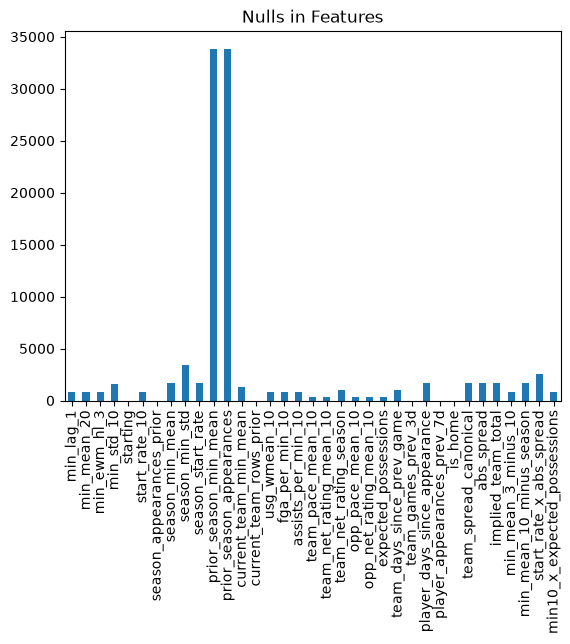

In [14]:
df[MIN_FEATURES].isna().sum().plot(kind='bar')
plt.title('Nulls in Features')
plt.show()


## 5. Data-quality checks

In [15]:
print(f"Number of rows : {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of Unique Players: {df['player_id'].nunique()}")
print(f"Number of Unique Games: {df['game_id'].nunique()}")
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Missing Labels: {df['minutes'].isna().sum()}")
print(f"Missing Start Position: {df['starting'].isna().sum()}")
print(f"Median Minutes: {df['minutes'].median()}")
print(f"Mean Minutes: {df['minutes'].mean().round(3)}")
print(f"Max Minutes: {df['minutes'].max().round(3)}")
print(f"Standard Deviation of Minutes: {df['minutes'].std().round(3)}")
print(f"Skewness of Minutes: {df['minutes'].skew().round(3)}")
print(f"Kurtosis of Minutes: {df['minutes'].kurt().round(3)}")
print(f"Percentage of players 20+ minutes: {round(df[df['minutes'] >= 20]['player_id'].nunique() / df['player_id'].nunique(), 3) * 100}%")
print(f"Percentage of players 30+ minutes: {round(df[df['minutes'] >= 30]['player_id'].nunique() / df['player_id'].nunique(), 3) * 100}%")
print(f"Percentage of players 40+ minutes: {round(df[df['minutes'] >= 40]['player_id'].nunique() / df['player_id'].nunique(), 1) * 100}%")

Number of rows : 79358
Number of columns: 237
Number of Unique Players: 802
Number of Unique Games: 3690
Total number of duplicates: 0
Missing Labels: 0
Missing Start Position: 0
Median Minutes: 23.516666666666666
Mean Minutes: 22.441
Max Minutes: 53.95
Standard Deviation of Minutes: 10.755
Skewness of Minutes: -0.272
Kurtosis of Minutes: -0.831
Percentage of players 20+ minutes: 87.7%
Percentage of players 30+ minutes: 74.6%
Percentage of players 40+ minutes: 40.0%


## 6. Train/validation/test design

In [16]:
df = df[(df['minutes'] > 0)]
print(f"After filtering minutes: {df[MIN_FEATURES].shape[0]} rows")


After filtering minutes: 79343 rows


In [17]:
splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["minutes"],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]


Train pool (excl. 2025-26) : 52,695 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2023-10-24 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


## 7. EDA

Checks on the appearance frame from section 6 (`minutes` > 0). Seasons through `2025-26` are included so a shift in that season is visible. Feature choice stays with the ablation in section 11.

- **Feature missingness.** Which of the 35 inputs are empty, overall and by season.
- **Outliers.** The minutes label, then inputs with a positive interquartile range whose values fall outside the Tukey fences.
- **Coverage by season.** Rows, players, games, and the share of rows where every input is present.
- **Drift.** Minutes and start rate across seasons. Start rate is the same-game `starting` flag and the pregame `start_rate_10` feature.

**Suspiciously predictive features.** Correlation with minutes uses seasons before `2025-26`. It flags a column that tracks tonight's minutes almost one-for-one. Recent-minutes features are built to track the label, so a large correlation stays in the model. The leave-one-out ablation in section 11 is the other half of this check: it measures how median pinball moves when each feature is removed.


### Feature missingness


Appearance rows: 79,343
Features with a null: 29 / 35
Rows with any null feature: 36,402 (45.9%)


,n_missing,pct_missing
prior_season_min_mean,33855,42.67
prior_season_appearances,33855,42.67
season_min_std,3425,4.32
start_rate_x_abs_spread,2504,3.16
implied_team_total,1730,2.18
player_days_since_appearance,1723,2.17
season_min_mean,1722,2.17
season_start_rate,1722,2.17
min_mean_10_minus_season,1722,2.17
team_spread_canonical,1707,2.15


,prior_season_min_mean,prior_season_appearances,season_min_std,start_rate_x_abs_spread,implied_team_total,player_days_since_appearance,season_min_mean,season_start_rate,min_mean_10_minus_season,team_spread_canonical,...,min_mean_20,min_ewm_hl_3,start_rate_10,min_mean_3_minus_10,min10_x_expected_possessions,team_pace_mean_10,team_net_rating_mean_10,opp_pace_mean_10,opp_net_rating_mean_10,expected_possessions
season_year,,,,,,,,,,,,,,,,,,,,,
2023-24,100.0,100.0,4.3,6.1,3.9,2.2,2.2,2.2,2.2,3.9,...,2.2,2.2,2.2,2.2,2.2,1.3,1.3,1.3,1.3,1.3
2024-25,14.2,14.2,4.3,0.7,0.2,2.2,2.2,2.2,2.2,0.2,...,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0
2025-26,14.0,14.0,4.4,2.7,2.4,2.2,2.2,2.2,2.2,2.3,...,0.4,0.4,0.4,0.4,0.4,0.0,0.0,0.0,0.0,0.0


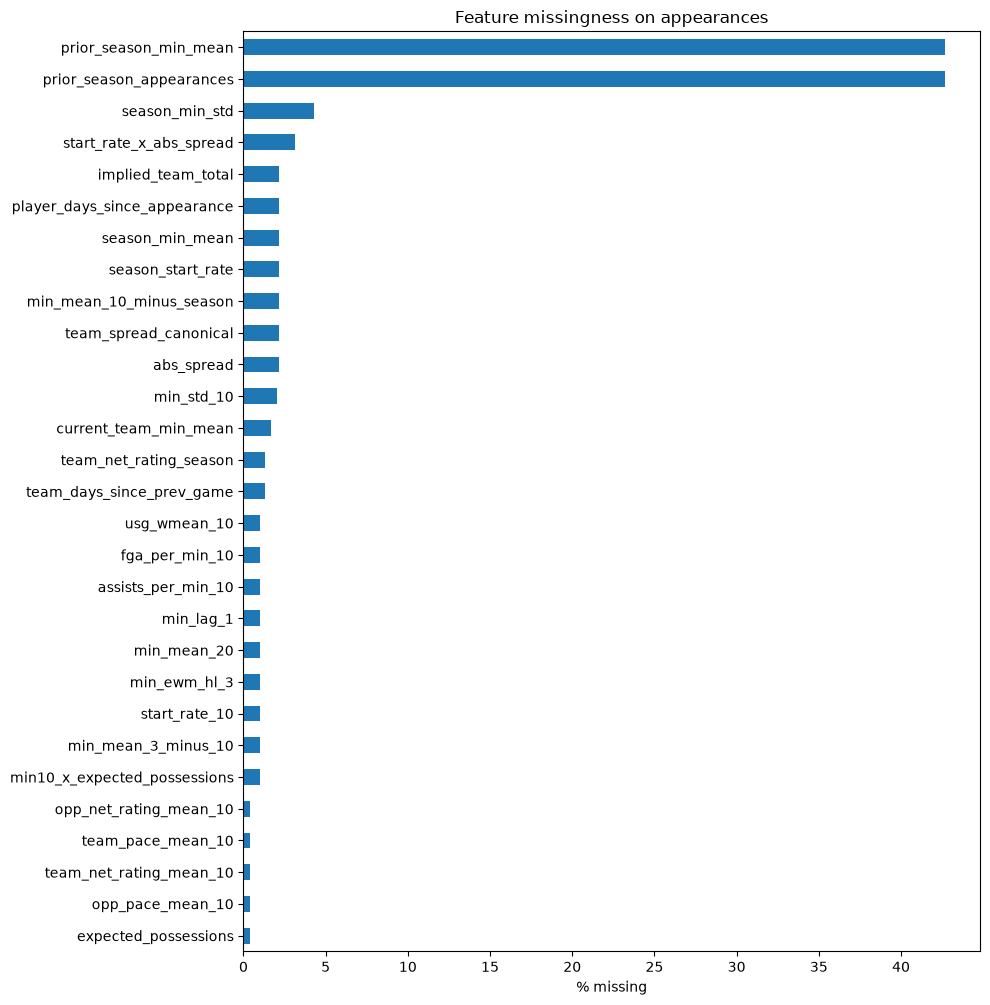

In [18]:
miss = pd.DataFrame({
    "n_missing": df[MIN_FEATURES].isna().sum(),
    "pct_missing": (df[MIN_FEATURES].isna().mean() * 100).round(2),
}).sort_values(["pct_missing", "n_missing"], ascending=False)

n_any = int(df[MIN_FEATURES].isna().any(axis=1).sum())
print(f"Appearance rows: {len(df):,}")
print(f"Features with a null: {int((miss['n_missing'] > 0).sum())} / {len(MIN_FEATURES)}")
print(f"Rows with any null feature: {n_any:,} ({n_any / len(df):.1%})")

sparse = miss.index[miss["n_missing"] > 0].tolist()
display(miss)
if sparse:
    season_miss_pct = (
        df[sparse]
        .isna()
        .groupby(df["season_year"], sort=True)
        .mean()
        .mul(100)
        .round(1)
    )
    display(season_miss_pct)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(sparse))))
    miss.loc[sparse, "pct_missing"].sort_values().plot.barh(ax=ax, color="C0")
    ax.set_xlabel("% missing")
    ax.set_title("Feature missingness on appearances")
    fig.tight_layout()
    plt.show()
else:
    print("Every selected feature is complete on this frame.")


### Outliers

Minutes outside the Tukey fence are overtime games. `player_days_since_appearance` is clipped at 30, and its fence is only a few days wide, so ordinary rest gaps fall outside it. The same is true of `player_appearances_prev_7d`.


n=79,343  min=0.02  p50=23.52  max=53.95
Tukey fence [-9.79, 55.61]  outside=0 (0.0%)
Player minutes above 48 (overtime range): 32


,season_year,game_date,player_name,minutes,starting
40346,2023-24,2024-04-07,Tyrese Maxey,53.950000,1
58815,2024-25,2025-04-01,Christian Braun,53.166667,1
12209,2024-25,2025-04-01,Nikola Jokić,52.633333,1
25969,2023-24,2024-04-14,Donte DiVincenzo,52.500000,1
40419,2025-26,2025-11-30,Tyrese Maxey,52.300000,1
5832,2023-24,2024-03-26,Anthony Davis,51.866667,1
2540,2025-26,2025-11-14,James Harden,51.050000,1
15944,2024-25,2025-01-06,Domantas Sabonis,50.483333,1


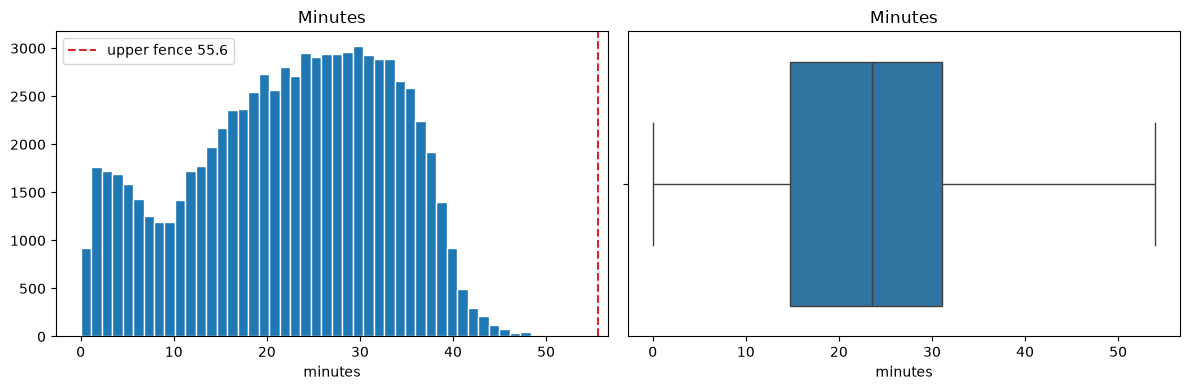

Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.


,feature,n,pct_outside,fence_low,fence_high,min,p50,max
0,player_days_since_appearance,77620,10.39,0.50,4.50,1.00,2.00,30.00
1,min_mean_10_minus_season,77621,8.94,-4.77,5.62,-22.51,0.06,30.54
2,player_appearances_prev_7d,79343,7.77,0.50,4.50,0.00,3.00,5.00
3,start_rate_x_abs_spread,76839,3.90,-7.50,12.50,0.00,1.35,25.50
4,min_mean_3_minus_10,78542,3.69,-7.87,8.00,-21.94,0.00,20.04
5,assists_per_min_10,78541,2.45,-0.06,0.25,0.00,0.09,1.22
6,season_min_std,75918,2.23,0.64,10.77,0.00,5.56,26.02
7,min_std_10,77750,2.06,-0.21,11.00,0.00,5.24,26.02
8,prior_season_appearances,45488,1.41,5.50,113.50,1.00,62.00,84.00
9,usg_wmean_10,78541,1.28,0.03,0.33,0.00,0.17,1.00


In [19]:
minutes = df["minutes"]
q1, q3 = minutes.quantile(0.25), minutes.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_tukey = int(((minutes < lo) | (minutes > hi)).sum())
n_ot = int((minutes > 48).sum())
print(
    f"n={len(minutes):,}  min={minutes.min():.2f}  "
    f"p50={minutes.median():.2f}  max={minutes.max():.2f}"
)
print(
    f"Tukey fence [{lo:.2f}, {hi:.2f}]  "
    f"outside={n_tukey:,} ({n_tukey / len(minutes):.1%})"
)
print(f"Player minutes above 48 (overtime range): {n_ot:,}")

top_minutes = (
    df.nlargest(8, "minutes")[
        ["season_year", "game_date", "player_name", "minutes", "starting"]
    ]
    .assign(game_date=lambda frame: pd.to_datetime(frame["game_date"]).dt.date)
)
display(top_minutes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(minutes, bins=48, color="C0", edgecolor="white")
axes[0].axvline(hi, color="C3", ls="--", label=f"upper fence {hi:.1f}")
axes[0].set_title("Minutes")
axes[0].set_xlabel("minutes")
axes[0].legend()
sns.boxplot(x=minutes, ax=axes[1], color="C0")
axes[1].set_title("Minutes")
fig.tight_layout()
plt.show()

outlier_rows = []
for col in MIN_FEATURES:
    values = df[col].dropna()
    if values.nunique(dropna=True) <= 2:
        continue
    fq1, fq3 = values.quantile([0.25, 0.75])
    spread = float(fq3 - fq1)
    if spread <= 0:
        continue
    fence_lo = float(fq1 - 1.5 * spread)
    fence_hi = float(fq3 + 1.5 * spread)
    outside = (values < fence_lo) | (values > fence_hi)
    outlier_rows.append({
        "feature": col,
        "n": int(values.shape[0]),
        "pct_outside": round(100 * float(outside.mean()), 2),
        "fence_low": round(fence_lo, 2),
        "fence_high": round(fence_hi, 2),
        "min": round(float(values.min()), 2),
        "p50": round(float(values.median()), 2),
        "max": round(float(values.max()), 2),
    })

feature_outliers = (
    pd.DataFrame(outlier_rows)
    .sort_values("pct_outside", ascending=False)
    .reset_index(drop=True)
)
print("Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.")
display(feature_outliers)


### Coverage by season

A row is complete when all 35 inputs are present. `2019-20` has none, because prior-season features are empty for the first season in the file.


In [20]:
complete = ~df[MIN_FEATURES].isna().any(axis=1)
coverage = df.groupby("season_year", sort=True).agg(
    rows=("player_id", "size"),
    players=("player_id", "nunique"),
    games=("game_id", "nunique"),
    first_game=("game_date", "min"),
    last_game=("game_date", "max"),
)
coverage["first_game"] = pd.to_datetime(coverage["first_game"]).dt.date
coverage["last_game"] = pd.to_datetime(coverage["last_game"]).dt.date
coverage["pct_rows_complete"] = (
    complete.groupby(df["season_year"], sort=True).mean().mul(100).round(1)
)
coverage["mean_missing_features"] = (
    df[MIN_FEATURES]
    .isna()
    .sum(axis=1)
    .groupby(df["season_year"], sort=True)
    .mean()
    .round(2)
)
print(f"Seasons: {len(coverage)}  rows: {int(coverage['rows'].sum()):,}")
display(coverage)


Seasons: 3  rows: 79,343


,rows,players,games,first_game,last_game,pct_rows_complete,mean_missing_features
season_year,,,,,,,
2023-24,26393,572,1230,2023-10-24,2024-04-14,0.0,2.66
2024-25,26302,569,1230,2024-10-22,2025-04-13,81.9,0.52
2025-26,26648,582,1230,2025-10-21,2026-04-12,80.3,0.59


### Drift in minutes and start rate

The minutes boxes hide points outside the whiskers so the season centers can be compared. The tails are in the outlier cell above.


,minutes_mean,minutes_p10,minutes_p50,minutes_p90,start_rate,start_rate_10
season_year,,,,,,
2023-24,22.497,5.500,23.517,36.433,0.466,0.458
2024-25,22.570,5.800,23.700,36.067,0.468,0.465
2025-26,22.272,6.167,23.350,35.100,0.462,0.461


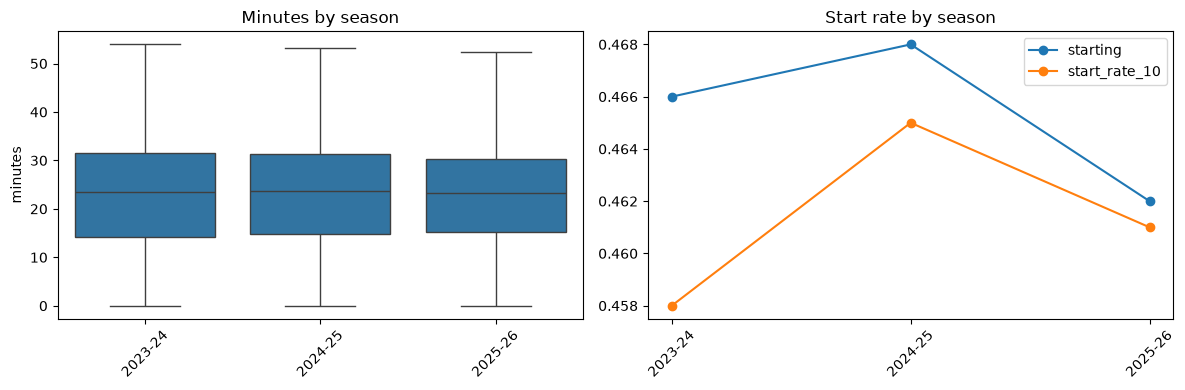

In [21]:
drift = (
    df.groupby("season_year", sort=True)
    .agg(
        minutes_mean=("minutes", "mean"),
        minutes_p10=("minutes", lambda s: s.quantile(0.10)),
        minutes_p50=("minutes", "median"),
        minutes_p90=("minutes", lambda s: s.quantile(0.90)),
        start_rate=("starting", "mean"),
        start_rate_10=("start_rate_10", "mean"),
    )
    .round(3)
)
display(drift)

order = [str(season) for season in drift.index]
plot_df = df.assign(season_year=df["season_year"].astype(str))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(
    data=plot_df,
    x="season_year",
    y="minutes",
    order=order,
    showfliers=False,
    ax=axes[0],
    color="C0",
)
axes[0].set_title("Minutes by season")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(order, drift["start_rate"].to_numpy(), marker="o", label="starting")
axes[1].plot(order, drift["start_rate_10"].to_numpy(), marker="o", label="start_rate_10")
axes[1].set_title("Start rate by season")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
fig.tight_layout()
plt.show()


### Suspiciously predictive features

Seasons before `2025-26` only. A column that matches tonight's minutes would show up here. Section 11's leave-one-out ablation is the pinball half of this check.


In [22]:
train_eda = df[df["season_year"].astype(str) != HOLDOUT_SEASON]
leaks = []
for col in MIN_FEATURES:
    pair = train_eda[[col, "minutes"]].dropna()
    if pair.empty:
        continue
    match = float((pair[col] == pair["minutes"]).mean())
    if match >= 0.99:
        leaks.append({
            "feature": col,
            "pct_equal_minutes": round(100 * match, 2),
            "n": len(pair),
        })

print(
    f"Train seasons only (holdout {HOLDOUT_SEASON} excluded): "
    f"{train_eda['season_year'].nunique()} seasons, {len(train_eda):,} rows"
)
if leaks:
    print("Features equal to minutes on at least 99% of non-null rows:")
    display(pd.DataFrame(leaks))
else:
    print("No feature equals minutes on 99% or more of its non-null rows.")

assoc = (
    train_eda[MIN_FEATURES]
    .corrwith(train_eda["minutes"])
    .rename("corr_with_minutes")
    .to_frame()
)
assoc["abs_corr"] = assoc["corr_with_minutes"].abs()
assoc = assoc.sort_values("abs_corr", ascending=False).round(3)
n_high = int((assoc["abs_corr"] >= 0.90).sum())
print(f"Features with |corr| >= 0.90: {n_high}")
print("Section 11 ablation scores the pinball change from removing each feature.")
display(assoc)


Train seasons only (holdout 2025-26 excluded): 2 seasons, 52,695 rows
No feature equals minutes on 99% or more of its non-null rows.
Features with |corr| >= 0.90: 0
Section 11 ablation scores the pinball change from removing each feature.


,corr_with_minutes,abs_corr
min_ewm_hl_3,0.804,0.804
min10_x_expected_possessions,0.789,0.789
min_mean_20,0.776,0.776
season_min_mean,0.772,0.772
current_team_min_mean,0.766,0.766
min_lag_1,0.749,0.749
starting,0.697,0.697
prior_season_min_mean,0.657,0.657
start_rate_10,0.656,0.656
season_start_rate,0.649,0.649


### Collinearity

Pairs with absolute correlation above 0.95. This is redundancy among inputs, separate from correlation with minutes.


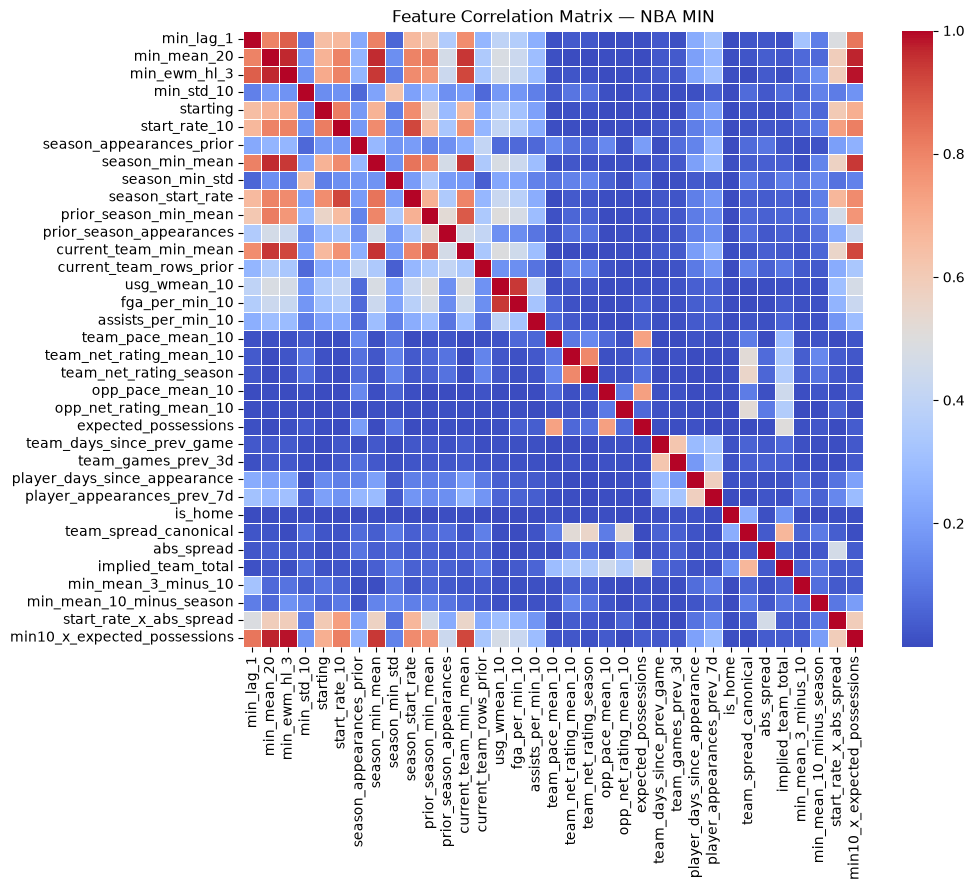

--- High Correlation Report (Threshold > 0.95) ---
min10_x_expected_possessions <-> min_ewm_hl_3: 0.9874
min10_x_expected_possessions <-> min_mean_20: 0.9720
min_ewm_hl_3 <-> min_mean_20: 0.9654
season_min_mean <-> min_mean_20: 0.9614
current_team_min_mean <-> season_min_mean: 0.9525


['min_ewm_hl_3',
 'season_min_mean',
 'current_team_min_mean',
 'min10_x_expected_possessions']

In [23]:
correlated_features = analyze_correlations(
    df, MIN_FEATURES, title="Feature Correlation Matrix — NBA MIN"
)
correlated_features


## 9. Evaluation protocol

### Evaluation

XGBoost quantile models only. Each split is scored with pinball loss at every trained quantile and with interval coverage for the 80% interval (q0.10–q0.90) and the 90% interval (q0.05–q0.95). The holdout also reports empirical calibration at each quantile, P(y ≤ q̂), interval sharpness as the mean and median width in minutes, the share of rows where a lower quantile exceeds a higher one, and minute tiers bucketed by predicted q50 rather than actual minutes.


## 10. Model comparison

In [24]:
# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=100, n_splits=5)
# XGB_PARAMS = result["best_params"]

In [25]:
tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  n= 8782
  pinball  | q0.05=0.613  q0.10=1.020  q0.50=2.325  q0.90=1.061  q0.95=0.630
  coverage | 80%=77.4% (target 80%)  90%=88.4% (target 90%)
  Starters   | n= 4075 | pinball q50: 2.234 | 80% coverage: 76.1%
  Bench      | n= 4707 | pinball q50: 2.404 | 80% coverage: 78.4%
  minute tiers by predicted q50
  <15 min    | n= 2265 | pinball q50: 2.507 | 80% coverage: 75.9%
  15-24 min  | n= 2125 | pinball q50: 2.443 | 80% coverage: 79.4%
  24-31 min  | n= 2326 | pinball q50: 2.324 | 80% coverage: 78.8%
  31+ min    | n= 2066 | pinball q50: 2.007 | 80% coverage: 75.2%

TSCV fold 2
  n= 8782
  pinball  | q0.05=0.633  q0.10=1.047  q0.50=2.310  q0.90=1.046  q0.95=0.625
  coverage | 80%=78.8% (target 80%)  90%=88.7% (target 90%)
  Starters   | n= 4116 | pinball q50: 2.175 | 80% coverage: 79.9%
  Bench      | n= 4666 | pinball q50: 2.430 | 80% coverage: 77.9%
  minute tiers by predicted q50
  <15 min    | n= 

In [26]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))


,split,quantile,pinball
0,WF fold 4 (2025-02-01 → 2025-03-10),0.05,0.6267
1,WF fold 4 (2025-02-01 → 2025-03-10),0.10,1.0253
2,WF fold 4 (2025-02-01 → 2025-03-10),0.50,2.2614
3,WF fold 4 (2025-02-01 → 2025-03-10),0.90,1.0192
4,WF fold 4 (2025-02-01 → 2025-03-10),0.95,0.6058


,split,interval,coverage,target
0,WF fold 4 (2025-02-01 → 2025-03-10),80%,0.7841,0.8
1,WF fold 4 (2025-02-01 → 2025-03-10),90%,0.8780,0.9


In [28]:
holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=MIN_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=MIN_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.614  q0.10=1.020  q0.50=2.263  q0.90=1.040  q0.95=0.629
  coverage | 80%=80.6% (target 80%)  90%=90.8% (target 90%)
  Starters   | n=12300 | pinball q50: 2.081 | 80% coverage: 81.1%
  Bench      | n=14348 | pinball q50: 2.419 | 80% coverage: 80.2%
  minute tiers by predicted q50
  <15 min    | n= 6472 | pinball q50: 2.575 | 80% coverage: 79.4%
  15-24 min  | n= 7248 | pinball q50: 2.354 | 80% coverage: 81.1%
  24-31 min  | n= 7456 | pinball q50: 2.174 | 80% coverage: 81.2%
  31+ min    | n= 5472 | pinball q50: 1.895 | 80% coverage: 80.6%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 2.214
  Holdout pinball q50             : 2.263
  Pinball gap                     : +0.049  ✓ acceptable
  Walk-forward 80% covera

,split,quantile,pinball
0,2025-26 holdout,0.05,0.6139
1,2025-26 holdout,0.10,1.0202
2,2025-26 holdout,0.50,2.2630
3,2025-26 holdout,0.90,1.0400
4,2025-26 holdout,0.95,0.6292


,split,interval,coverage,target
0,2025-26 holdout,80%,0.8061,0.8
1,2025-26 holdout,90%,0.9078,0.9


In [29]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler

X_lin_train = ppm_df[MIN_FEATURES]
y_lin_train = ppm_df[TARGET_COL].to_numpy(dtype=float)
X_lin_ho = ppm_holdout[MIN_FEATURES]
y_lin_ho = ppm_holdout[TARGET_COL].to_numpy(dtype=float)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_lin_train_s = scaler.fit_transform(imputer.fit_transform(X_lin_train))
X_lin_ho_s = scaler.transform(imputer.transform(X_lin_ho))

preds_lin = {}
for alpha in QUANTILES:
    reg = QuantileRegressor(quantile=alpha, alpha=0.0, solver="highs")
    reg.fit(X_lin_train_s, y_lin_train)
    preds_lin[f"q_{alpha:.2f}"] = reg.predict(X_lin_ho_s)
    print(f"fit q_{alpha:.2f}")

lin_pinball, lin_coverage = score_predictions(
    y_lin_ho, preds_lin, f"{HOLDOUT_SEASON} linear"
)

cmp_pinball = (
    ho_pinball[["quantile", "pinball"]]
    .merge(
        lin_pinball[["quantile", "pinball"]],
        on="quantile",
        suffixes=("_xgb", "_linear"),
    )
)
cmp_pinball["xgb_minus_linear"] = (
    cmp_pinball["pinball_xgb"] - cmp_pinball["pinball_linear"]
)
cmp_coverage = (
    ho_coverage[["interval", "coverage", "target"]]
    .merge(
        lin_coverage[["interval", "coverage"]],
        on="interval",
        suffixes=("_xgb", "_linear"),
    )
)

print(
    f"{HOLDOUT_SEASON} holdout — linear quantile vs XGBoost\n"
    f"  train rows {len(y_lin_train):,} | holdout rows {len(y_lin_ho):,}\n"
    "  xgb_minus_linear < 0 means the XGBoost pinball is lower"
)
display(cmp_pinball.round(4))
display(cmp_coverage.round(4))

fit q_0.05
fit q_0.10
fit q_0.50
fit q_0.90
fit q_0.95
2025-26 holdout — linear quantile vs XGBoost
  train rows 52,695 | holdout rows 26,648
  xgb_minus_linear < 0 means the XGBoost pinball is lower


,quantile,pinball_xgb,pinball_linear,xgb_minus_linear
0,0.05,0.6139,0.6427,-0.0288
1,0.10,1.0202,1.0676,-0.0474
2,0.50,2.2630,2.3197,-0.0567
3,0.90,1.0400,1.0389,0.0012
4,0.95,0.6292,0.6181,0.0111


,interval,coverage_xgb,target,coverage_linear
0,80%,0.8061,0.8,0.7915
1,90%,0.9078,0.9,0.8967


In [30]:
y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

sharpness_rows = []
for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in preds_ho or high_key not in preds_ho:
        continue
    width = (
        np.asarray(preds_ho[high_key], dtype=float)
        - np.asarray(preds_ho[low_key], dtype=float)
    )
    sharpness_rows.append({
        "interval": f"{nominal:.0%}",
        "coverage": interval_coverage(y_true, preds_ho[low_key], preds_ho[high_key]),
        "target": nominal,
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
    })
sharpness = pd.DataFrame(sharpness_rows)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))
print(f"{HOLDOUT_SEASON} holdout — interval sharpness (minutes)")
display(sharpness.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0538,0.0038
1,0.10,0.10,0.1053,0.0053
2,0.50,0.50,0.5024,0.0024
3,0.90,0.90,0.9114,0.0114
4,0.95,0.95,0.9615,0.0115


2025-26 holdout — interval sharpness (minutes)


,interval,coverage,target,mean_width,median_width
0,80%,0.8061,0.8,14.8190,14.6722
1,90%,0.9078,0.9,19.7705,19.9196


In [31]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 22 / 26,648 rows (0.1%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0008
1,q_0.10,q_0.50,0.0000
2,q_0.50,q_0.90,0.0000
3,q_0.90,q_0.95,0.0000


In [32]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in MIN_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — minute tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — minute tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<15 min,6472,0.2429,2.5746,0.5036,0.7937,0.9034,16.9836,22.6722
1,15-24 min,7248,0.2720,2.3543,0.4873,0.8110,0.9160,15.6566,21.1977
2,24-31 min,7456,0.2798,2.1742,0.5111,0.8118,0.9071,14.3646,18.8331
3,31+ min,5472,0.2053,1.8946,0.5093,0.8065,0.9030,11.7688,15.7255


## 11. Error analysis


── q_0.05 ──


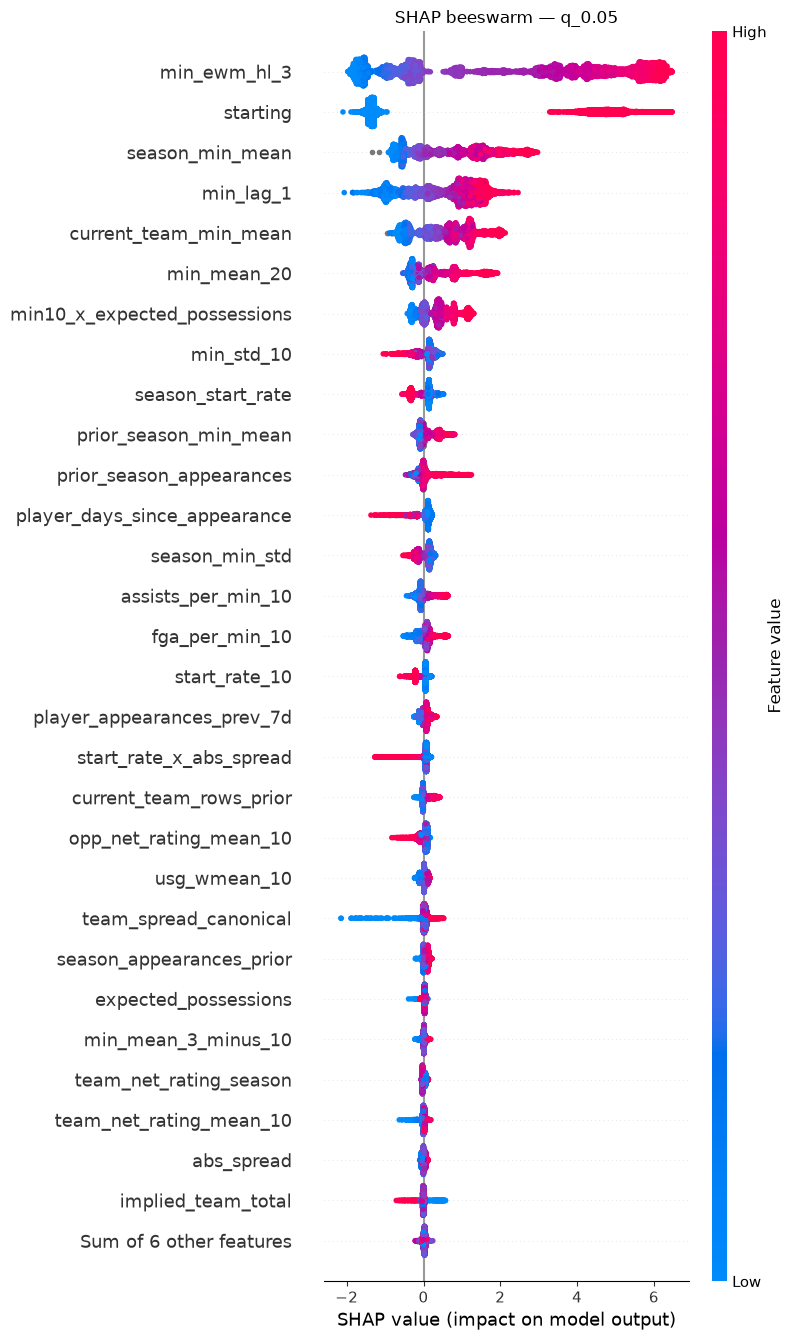


── q_0.10 ──


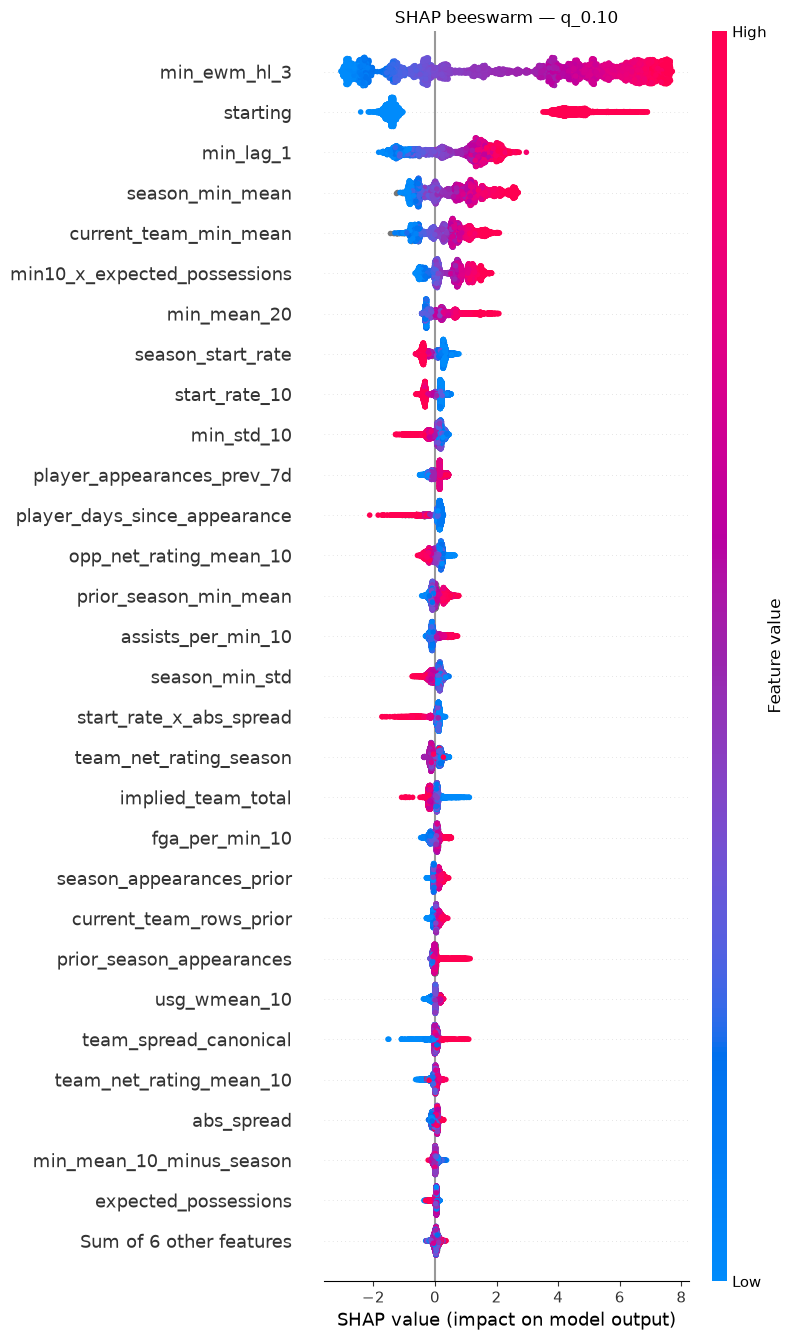


── q_0.50 ──


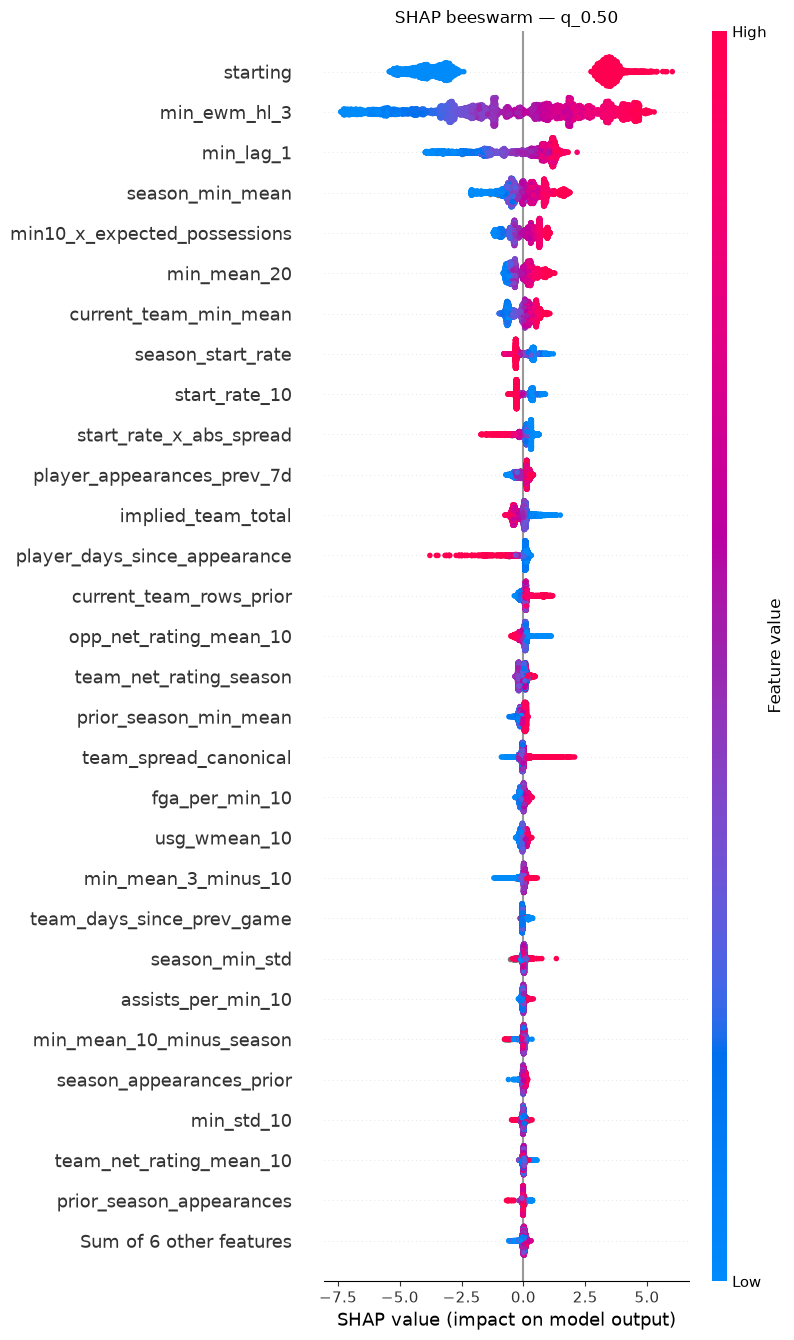


── q_0.90 ──


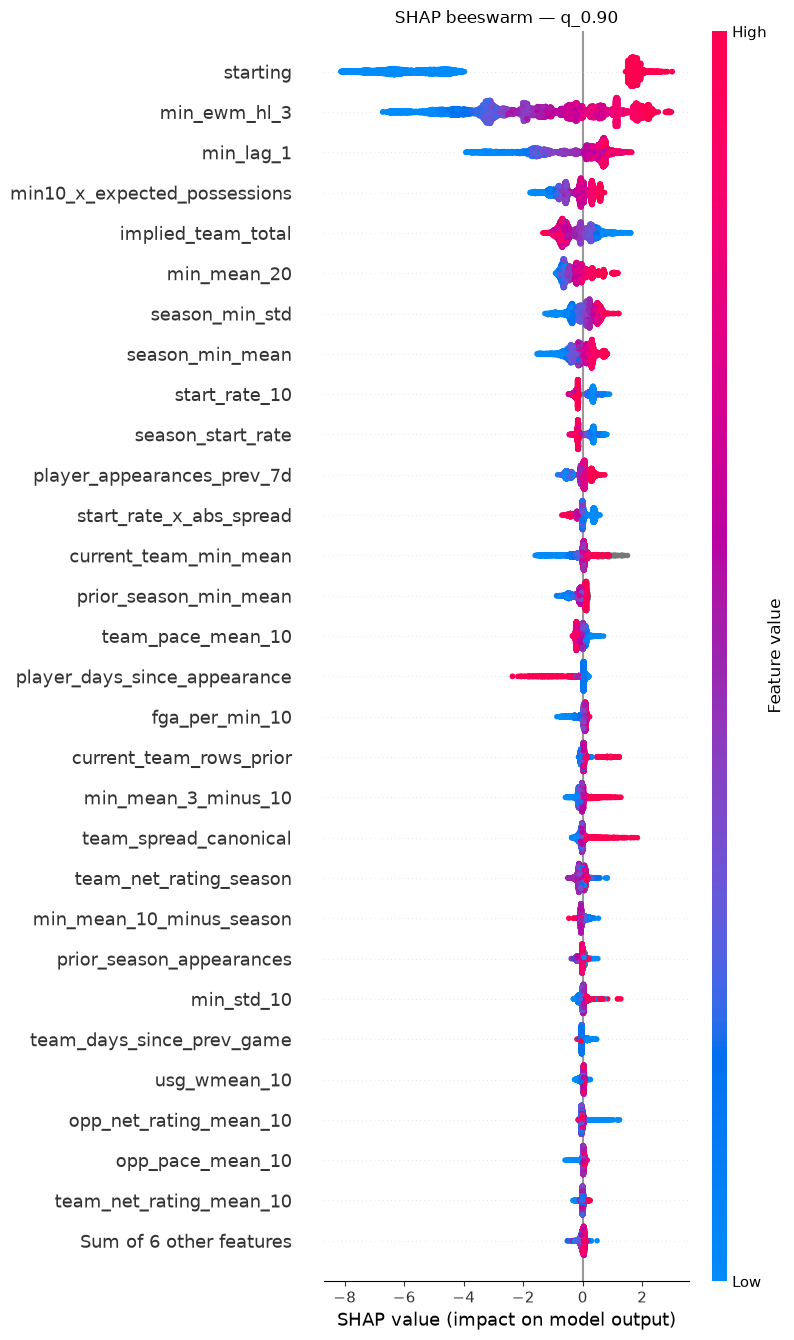


── q_0.95 ──


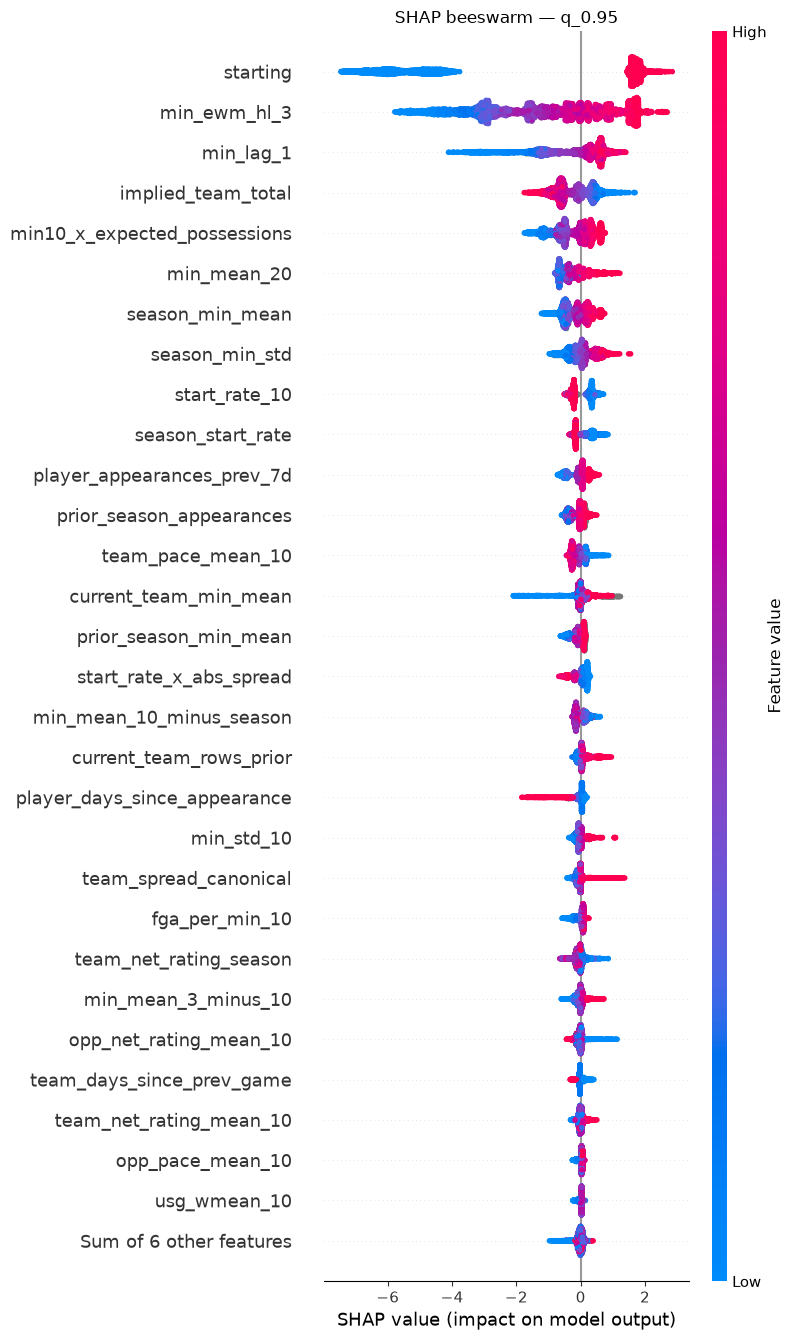

In [33]:
import shap

for q_key, model in models_last.items():
    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()


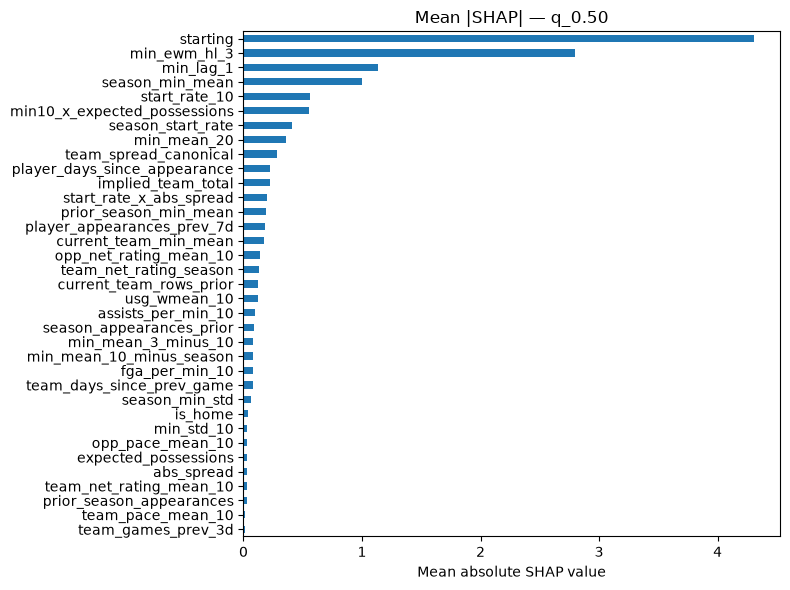

In [12]:
model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                         feature  importance      std  p_value  significant
1                       starting     1.10067  0.01786   0.0000         True
2                   min_ewm_hl_3     0.74713  0.01093   0.0000         True
3                      min_lag_1     0.17077  0.00570   0.0000         True
4                season_min_mean     0.14370  0.00426   0.0000         True
5                  start_rate_10     0.06948  0.00321   0.0000         True
6   min10_x_expected_possessions     0.03958  0.00214   0.0000         True
7              season_start_rate     0.03567  0.00237   0.0000         True
8          team_spread_canonical     0.02414  0.00229   0.0000         True
9                    min_mean_20     0.02113  0.00149   0.0000         True
10  player_days_since_appearance     0.01921  0.00207   0.0000         True
11       start_rate_x_abs_spread     0.01079  0.00145   0.0000         True
12     

In [14]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

ablation_df = run_feature_ablation(
    MIN_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline pinball q50 (all features): 2.2515
                         feature  ablated_pinball  delta_pinball
1                       starting           2.3627         0.1112
2                      min_lag_1           2.2625         0.0110
3   player_days_since_appearance           2.2552         0.0037
4                 season_min_std           2.2540         0.0026
5         opp_net_rating_mean_10           2.2541         0.0026
6                 fga_per_min_10           2.2534         0.0019
7              season_start_rate           2.2532         0.0017
8      team_days_since_prev_game           2.2530         0.0015
9             implied_team_total           2.2528         0.0013
10            assists_per_min_10           2.2525         0.0010
11         current_team_min_mean           2.2522         0.0008
12                    min_std_10           2.2518         0.0004
13                       is_home           2.2518         0.0004
14    player_appearances_prev_7d           2.2

In [28]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                         feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1                       starting       4.311008          1          1          1.10067              0.01786  1.828700e-53          0.1112   1.000000   1.000000   1.000000   True
2                   min_ewm_hl_3       2.796879          2          2          0.74713              0.01093  9.172233e-55          0.0001   0.648776   0.678796   0.663786   True
3                      min_lag_1       1.131233          3          3          0.17077              0.00570  2.142242e-44          0.0110   0.262406   0.155151   0.208778   True
4                season_min_mean       1.003439          4          4          0.14370              0.00426  7.118419e-46         -0.0002   0.232762   0.130557   0.181659  False
5                  start_rate_10       0.557198          5          5          0.06948              0.00321  2

## 8. Baselines

XGBoost q50 against the linear quantile median, last-game minutes, the season-to-date average, and EWMA, on the same holdout rows. This cell follows both holdout fits because it reads those predictions.

In [34]:
N_BOOT = 2_000
SEED = 42

y = np.asarray(y_ho, dtype=float)
predictors = {
    "model": np.asarray(preds_ho["q_0.50"], dtype=float),
    "linear": np.asarray(preds_lin["q_0.50"], dtype=float),
    "season_average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "last_game": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "ewma": ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float),
}
dates = ppm_holdout["game_date"].to_numpy()
finite = np.isfinite(y)
for pred in predictors.values():
    finite &= np.isfinite(pred)
n_dropped = int((~finite).sum())

y = y[finite]
dates = dates[finite]
predictors = {name: pred[finite] for name, pred in predictors.items()}
codes, _unique_dates = pd.factorize(dates, sort=False)
n_clusters = int(codes.max()) + 1
abs_err = {name: np.abs(y - pred) for name, pred in predictors.items()}
cluster_n = np.bincount(codes).astype(float)
cluster_sum = {
    name: np.bincount(codes, weights=err) for name, err in abs_err.items()
}

rng = np.random.default_rng(SEED)
draws = rng.integers(0, n_clusters, size=(N_BOOT, n_clusters))
weights = np.zeros((N_BOOT, n_clusters), dtype=np.int32)
np.add.at(
    weights,
    (np.repeat(np.arange(N_BOOT), n_clusters), draws.ravel()),
    1,
)
denom = weights @ cluster_n
boot_mae = {
    name: (weights @ cluster_sum[name]) / denom for name in predictors
}
point = {name: float(err.mean()) for name, err in abs_err.items()}

labels = {
    "model": "XGBoost (q50)",
    "linear": "Linear quantile (q50)",
    "season_average": "Season average",
    "last_game": "Last-game minutes",
    "ewma": "EWMA (halflife 3)",
}
order = ["model", "linear", "season_average", "last_game", "ewma"]
mae_table = pd.DataFrame([
    {
        "predictor": labels[name],
        "mae": point[name],
        "ci_low": float(np.quantile(boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae[name], 0.975)),
    }
    for name in order
])
delta_table = pd.DataFrame([
    {
        "comparison": f"XGBoost − {labels[name]}",
        "delta_mae": point["model"] - point[name],
        "ci_low": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.975)),
    }
    for name in order[1:]
])

print(
    f"{HOLDOUT_SEASON} holdout MAE \u2014 paired bootstrap clustered by game date\n"
    f"  {N_BOOT:,} resamples | {n_clusters:,} dates | {len(y):,} rows"
    f" | dropped {n_dropped:,} rows with a missing baseline"
)
display(mae_table.round(3))
print("Paired difference (negative means the model has lower MAE)")
display(delta_table.round(3))


2025-26 holdout MAE — paired bootstrap clustered by game date
  2,000 resamples | 162 dates | 26,066 rows | dropped 582 rows with a missing baseline


,predictor,mae,ci_low,ci_high
0,Model (q50),4.479,4.408,4.565
1,Season average,5.298,5.168,5.456
2,Last-game minutes,5.766,5.663,5.871
3,EWMA (halflife 3),4.933,4.834,5.061


Paired difference (negative means the model has lower MAE)


,comparison,delta_mae,ci_low,ci_high
0,model − Season average,-0.819,-0.909,-0.734
1,model − Last-game minutes,-1.287,-1.348,-1.227
2,model − EWMA (halflife 3),-0.454,-0.509,-0.406


### Frozen minutes acceptance report

Identical holdout rows for the quantile model against last-game minutes, the season-to-date average, and EWMA. Distribution scores, per-quantile calibration, and pregame slices follow. Walk-forward fold MAEs use the saved q50 pinball.

In [35]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

y_all = np.asarray(y_ho, dtype=float)
quantiles = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
alpha_of = {key: float(str(key).split("_", 1)[1]) for key in quantiles}
ordered_keys = sorted(quantiles, key=alpha_of.get)
model = quantiles["q_0.50"]
baselines = {
    "Last-game minutes": ppm_holdout["min_lag_1"].to_numpy(dtype=float),
    "Season-to-date average": ppm_holdout["season_min_mean"].to_numpy(dtype=float),
    "EWMA minutes": ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all) & np.isfinite(model)
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
paired_preds = {"Quantile XGBoost q50": model[paired]}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game minutes",
    "Season-to-date average",
    "EWMA minutes",
    "Quantile XGBoost q50",
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae["Quantile XGBoost q50"]
delta_table = pd.DataFrame([
    {
        "comparison": f"q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == "Quantile XGBoost q50", "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "min_lag_1"),
        ("season_average", "season_min_mean"),
        ("ewma", "min_ewm_hl_3"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"q50 pinball {pinball_loss(y_paired, paired_preds['Quantile XGBoost q50'], 0.50):.4f} "
    "equals half the q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward model MAE is 2 × q50 pinball on every validation row. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

print("\n2. Distribution quality")
width_80 = quantiles["q_0.90"] - quantiles["q_0.10"]
width_90 = quantiles["q_0.95"] - quantiles["q_0.05"]
grid = np.column_stack([quantiles[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
distribution = pd.DataFrame([
    {
        "cov_80": interval_coverage(y_all, quantiles["q_0.10"], quantiles["q_0.90"]),
        "width_80_mean": float(width_80.mean()),
        "width_80_median": float(np.median(width_80)),
        "cov_90": interval_coverage(y_all, quantiles["q_0.05"], quantiles["q_0.95"]),
        "width_90_mean": float(width_90.mean()),
        "width_90_median": float(np.median(width_90)),
        "wis": float(np.mean(wis_values(y_all, quantiles))),
        "quantile_crossing": float(crossed.mean()),
    }
])
display(distribution.round(4))
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS. Model WIS is the distribution score."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= quantiles[key])),
        "difference": float(np.mean(y_all <= quantiles[key]) - alpha_of[key]),
    }
    for key in ordered_keys
])
display(calibration.round(4))

def subgroup_row(name, mask):
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y_all) & np.isfinite(model)
    n = int(mask.sum())
    if n == 0:
        return None
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in quantiles.items()}
    error = y - qmap["q_0.50"]
    return {
        "group": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "wis": float(np.mean(wis_values(y, qmap))),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "width_80_mean": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "width_80_median": float(np.median(qmap["q_0.90"] - qmap["q_0.10"])),
        "cov_90": interval_coverage(y, qmap["q_0.05"], qmap["q_0.95"]),
        "width_90_mean": float(np.mean(qmap["q_0.95"] - qmap["q_0.05"])),
        "width_90_median": float(np.median(qmap["q_0.95"] - qmap["q_0.05"])),
    }

print("\n4. Pregame-defined subgroups")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
subgroup_rows = [
    subgroup_row("Confirmed starter", starting == 1),
    subgroup_row("Bench", starting == 0),
]
for name, fn in MIN_TIERS.items():
    subgroup_rows.append(subgroup_row(f"Predicted q50 {name}", fn(model)))
for month in sorted(months.unique()):
    subgroup_rows.append(subgroup_row(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame([row for row in subgroup_rows if row is not None])
display(subgroup_table.round(3))

print("\n5. Tail failures")
absolute_error = np.abs(y_all - model)
tail_table = pd.DataFrame([
    {
        "threshold": f">{cutoff:g} min",
        "rate": float(np.mean(absolute_error > cutoff)),
        "n": int(np.sum(absolute_error > cutoff)),
    }
    for cutoff in (5, 10, 15)
])
display(tail_table.round(4))

q50_rate = float(calibration.loc[calibration["quantile"] == "q50", "observed"].iloc[0])
max_gap = float(calibration["difference"].abs().max())
best_delta = delta_table.loc[delta_table["comparison"] == f"q50 − {best_name}"].iloc[0]
model_wis = float(distribution["wis"].iloc[0])
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
print(f"  q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
print(f"  largest |quantile gap| {max_gap:.1%}")
print(
    f"  q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(f"  model WIS {model_wis:.3f} vs best baseline CRPS/MAE {best_mae:.3f}")
print(
    "  walk-forward folds with model MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(f"  raw quantile crossing {float(crossed.mean()):.2%} of rows")


1. Point accuracy versus baselines
Identical holdout rows: 26,066  |  dropped 582 with a missing baseline  |  2,000 date-clustered resamples
Mean bias is actual minus predicted. q50 pinball 2.2396 equals half the q50 MAE.


,model,mae,median_ae,mean_bias
0,Last-game minutes,5.766,4.417,0.083
1,Season-to-date average,5.298,4.143,0.624
2,EWMA minutes,4.933,3.887,0.099
3,Quantile XGBoost q50,4.479,3.505,-0.048


Paired MAE difference, clustered by game date. Negative means q50 is lower.


,comparison,delta_mae,ci_low,ci_high
0,q50 − Last-game minutes,-1.287,-1.348,-1.227
1,q50 − Season-to-date average,-0.819,-0.909,-0.734
2,q50 − EWMA minutes,-0.454,-0.509,-0.406


Walk-forward model MAE is 2 × q50 pinball on every validation row. Baseline MAE drops rows with no prior.


...


4. Pregame-defined subgroups


,group,n,mae,bias,wis,cov_80,width_80_mean,width_80_median,cov_90,width_90_mean,width_90_median
0,Confirmed starter,12300,4.144,-0.599,2.876,0.808,13.194,12.993,0.903,17.196,16.854
1,Bench,14348,4.804,0.482,3.277,0.791,15.122,15.054,0.890,19.484,19.486
2,Predicted q50 <15 min,6384,5.130,1.006,3.463,0.780,15.762,15.934,0.884,19.939,20.021
3,Predicted q50 15-24 min,7328,4.654,0.122,3.194,0.800,14.996,14.769,0.896,19.606,19.462
4,Predicted q50 24-31 min,7280,4.340,-0.409,2.993,0.806,13.977,13.731,0.899,18.034,17.746
5,Predicted q50 31+ min,5656,3.793,-0.847,2.665,0.808,11.840,11.778,0.904,15.703,15.494
6,2025-10,1791,4.547,0.068,3.155,0.794,14.416,14.119,0.894,18.681,18.393
7,2025-11,4784,4.379,0.074,3.017,0.806,13.935,13.637,0.897,17.984,17.749
8,2025-12,4265,4.454,-0.130,3.065,0.798,14.110,13.786,0.891,18.214,17.978
9,2026-01,4987,4.263,-0.145,2.939,0.817,14.105,13.821,0.908,18.268,18.122



5. Tail failures


,threshold,rate,n
0,>5 min,0.3467,9240
1,>10 min,0.0883,2352
2,>15 min,0.0215,574



Checks from this frame
  q50 observed rate 50.5%  (target about 48–52%)
  largest |quantile gap| 0.8%
  q50 vs EWMA minutes: delta MAE -0.454 [-0.509, -0.406]
  model WIS 3.091 vs best baseline CRPS/MAE 4.933
  walk-forward folds with model MAE below the best baseline: 4 / 4
  raw quantile crossing 0.47% of rows


In [37]:
MODEL_WIS_REFERENCE = 3.092
LINE_PROXY_CUTOFFS = (15, 20)

train_y = ppm_df["minutes"].to_numpy(dtype=float)
train_ewma = ppm_df["min_ewm_hl_3"].to_numpy(dtype=float)
train_ok = np.isfinite(train_y) & np.isfinite(train_ewma)
train_residual = train_y[train_ok] - train_ewma[train_ok]

hold_y = np.asarray(y_ho, dtype=float)
hold_ewma = ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float)
hold_season = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
model_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
levels = sorted(model_q, key=lambda key: float(str(key).split("_", 1)[1]))
residual_q = {
    key: float(np.quantile(train_residual, float(str(key).split("_", 1)[1])))
    for key in levels
}
ewma_q = {key: hold_ewma + shift for key, shift in residual_q.items()}
scored = np.isfinite(hold_y) & np.isfinite(hold_ewma)

def _wis(mask, qmap):
    y = hold_y[mask]
    sliced = {key: values[mask] for key, values in qmap.items()}
    return float(np.mean(wis_values(y, sliced)))

model_wis_all = _wis(np.isfinite(hold_y), model_q)
model_wis_paired = _wis(scored, model_q)
ewma_wis_paired = _wis(scored, ewma_q)
baseline = pd.DataFrame([
    {
        "distribution": "Quantile XGBoost",
        "rows": "all holdout",
        "n": int(np.isfinite(hold_y).sum()),
        "wis": model_wis_all,
        "cov_80": interval_coverage(
            hold_y, model_q["q_0.10"], model_q["q_0.90"]
        ),
        "mean_width_80": float(np.mean(model_q["q_0.90"] - model_q["q_0.10"])),
    },
    {
        "distribution": "Quantile XGBoost",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": model_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], model_q["q_0.10"][scored], model_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(model_q["q_0.90"][scored] - model_q["q_0.10"][scored])
        ),
    },
    {
        "distribution": "EWMA + train residuals",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": ewma_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], ewma_q["q_0.10"][scored], ewma_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(ewma_q["q_0.90"][scored] - ewma_q["q_0.10"][scored])
        ),
    },
])
print(
    "EWMA quantile distribution = min_ewm_hl_3 + residual quantiles from the "
    f"training pool only ({int(train_ok.sum()):,} rows). Holdout outcomes are not in that pool."
)
print(
    f"Reported model WIS was {MODEL_WIS_REFERENCE:.3f}. "
    f"Recomputed on all holdout rows: {model_wis_all:.3f}. "
    f"On the shared EWMA rows, model WIS {model_wis_paired:.3f} vs "
    f"EWMA distribution WIS {ewma_wis_paired:.3f} "
    f"(delta {model_wis_paired - ewma_wis_paired:+.3f}; negative means the model is better)."
)
display(baseline.round(3))

pregame = np.where(np.isfinite(hold_ewma), hold_ewma, hold_season)
proxy_rows = []
for cutoff in LINE_PROXY_CUTOFFS:
    mask = np.isfinite(hold_y) & np.isfinite(pregame) & (pregame >= cutoff)
    y = hold_y[mask]
    q50 = model_q["q_0.50"][mask]
    proxy_rows.append({
        "proxy": f"pregame EWMA >= {cutoff:g}",
        "n": int(mask.sum()),
        "share": float(mask.mean()),
        "mae": float(np.mean(np.abs(y - q50))),
        "wis": _wis(mask, model_q),
        "cov_80": interval_coverage(y, model_q["q_0.10"][mask], model_q["q_0.90"][mask]),
        "mean_width_80": float(np.mean(model_q["q_0.90"][mask] - model_q["q_0.10"][mask])),
    })
print(
    "No minutes-line file is available. Bookmakers usually post players expected "
    "to play a regular shift. The table uses pregame EWMA (season average if EWMA "
    "is missing), not minutes played in that game. It is not the posted-line population."
)
display(pd.DataFrame(proxy_rows).round(3))
print(
    "Frozen. Do not change features, quantiles, or XGB_PARAMS to improve 2025-26. "
    "The open checks are this EWMA distribution comparison and, later, rows that "
    "actually had a posted minutes line."
)


EWMA quantile distribution = min_ewm_hl_3 + residual quantiles from the training pool only (148,994 rows). Holdout outcomes are not in that pool.
Reported model WIS was 3.092. Recomputed on all holdout rows: 3.091. On the shared EWMA rows, model WIS 3.087 vs EWMA distribution WIS 3.473 (delta -0.386; negative means the model is better).


,distribution,rows,n,wis,cov_80,mean_width_80
0,Quantile XGBoost,all holdout,26648,3.091,0.799,14.232
1,Quantile XGBoost,EWMA available,26544,3.087,0.799,14.220
2,EWMA + train residuals,EWMA available,26544,3.473,0.805,15.859


No minutes-line file is available. Bookmakers usually post players expected to play a regular shift. The table uses pregame EWMA (season average if EWMA is missing), not minutes played in that game. It is not the posted-line population.


,proxy,n,share,mae,wis,cov_80,mean_width_80
0,pregame EWMA >= 15,20625,0.774,4.323,2.988,0.802,13.748
1,pregame EWMA >= 20,16377,0.615,4.154,2.882,0.805,13.222


Frozen. Do not change features, quantiles, or XGB_PARAMS to improve 2025-26. The open checks are this EWMA distribution comparison and, later, rows that actually had a posted minutes line.


## 11. Error analysis (continued)

### Follow-ups before freezing

April versus the rest of the regular season, starter and bench median calibration, monotone quantile rearrangement, and the cold-start rows.

In [36]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.2f} min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["min_ewm_hl_3"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, "minutes"].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_min_mean is missing. "
    "If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,4.429,-0.044,0.504,0.805,14.149,3.048
1,March 1–14,2364,4.526,-0.035,0.503,0.780,14.268,3.082
2,March 15–31,2806,4.444,-0.222,0.516,0.800,14.320,3.021
3,April regular season,2061,5.206,0.538,0.502,0.757,14.849,3.611


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,4.144,-0.599,0.521,0.808,13.194,2.876
1,Bench,14348,4.804,0.482,0.492,0.791,15.122,3.277


  Confirmed starter: bias -0.60 min, P(actual <= q50) 52.1%. q50 is too high: actuals fall under the median more often than 50%.
  Bench: bias +0.48 min, P(actual <= q50) 49.2%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 0.47% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0003,0.0016
1,q_0.10,0.0004,0.0023
2,q_0.20,0.0003,0.0020
3,q_0.30,0.0002,0.0015
4,q_0.40,0.0001,0.0010
5,q_0.50,0.0002,0.0009
6,q_0.60,0.0001,0.0004
7,q_0.70,0.0000,0.0002
8,q_0.80,0.0000,0.0002
9,q_0.90,0.0000,0.0001


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,5.262,0.776,0.483,0.787,15.984,3.676
1,"No prior game, model",104,6.008,4.039,0.423,0.798,17.279,4.124
2,"No prior game, role fallback",104,9.345,-6.079,0.769,0.712,23.154,5.653
3,"Any missing baseline, model",582,5.396,1.359,0.473,0.789,16.216,3.756


Live fallback: if min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_min_mean is missing. If min_lag_1 is missing, do not use the tree. Use the training-pool minute quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Minutes tail shape and 2025-26 CRPS record

Folds 1–2 define an in-memory diagnostic tail shape, scored on folds 3–4 only. The sidecar written below uses folds 1–4. The 2025-26 holdout numbers are a record: they are not a reason to edit the tables, the grouping rule, the floor, or the train-tail stopping setting.

In [40]:
from models.shared.minutes_sampler import (
    QUANTILE_LEVELS,
    build_tail_tables,
    groups_for_frame,
    prepare_quantile_grid,
    quantile_minutes,
    row_crps,
    save_tail_sidecar,
    tail_bin_shares,
)

LOWER_EDGE_U = np.asarray([0.01, 0.02, 0.03, 0.04, 0.05], dtype=float)
UPPER_EDGE_U = np.asarray([0.95, 0.96, 0.97, 0.98, 0.99], dtype=float)
Q50_TIERS = (
    ("<15", lambda q: q < 15),
    ("15-24", lambda q: (q >= 15) & (q < 24)),
    ("24-31", lambda q: (q >= 24) & (q < 31)),
    ("31+", lambda q: q >= 31),
)
KNOT_COLS = [f"q_{level:.2f}" for level in QUANTILE_LEVELS]
Q50_INDEX = list(QUANTILE_LEVELS).index(0.50)


def clustered_share_bootstrap(y, edges, dates, *, tail, n_boot=N_BOOT, seed=SEED):
    """Date-clustered CI for tail_bin_shares, matching clustered_mae_bootstrap."""
    point = tail_bin_shares(y, edges, tail=tail)
    actual = np.asarray(y, dtype=float)
    edge_mat = np.asarray(edges, dtype=float)
    if edge_mat.ndim == 1:
        edge_mat = edge_mat.reshape(1, -1)
    n_rows, n_bins = edge_mat.shape
    in_bin = np.zeros((n_rows, n_bins), dtype=float)
    if tail == "lower":
        misses = (actual < edge_mat[:, -1]).astype(float)
        for bin_index in range(n_bins):
            if bin_index == 0:
                in_bin[:, bin_index] = actual < edge_mat[:, 0]
            else:
                in_bin[:, bin_index] = (
                    (actual >= edge_mat[:, bin_index - 1])
                    & (actual < edge_mat[:, bin_index])
                )
    elif tail == "upper":
        misses = (actual > edge_mat[:, 0]).astype(float)
        for bin_index in range(n_bins):
            if bin_index == n_bins - 1:
                in_bin[:, bin_index] = actual > edge_mat[:, -1]
            else:
                in_bin[:, bin_index] = (
                    (actual > edge_mat[:, bin_index])
                    & (actual <= edge_mat[:, bin_index + 1])
                )
    else:
        raise ValueError(f"unknown tail {tail}")

    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_miss = np.bincount(codes, weights=misses)
    cluster_bins = np.column_stack([
        np.bincount(codes, weights=in_bin[:, bin_index])
        for bin_index in range(n_bins)
    ])
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom_rows = weights @ cluster_n
    denom_miss = weights @ cluster_miss
    boot_counts = weights @ cluster_bins
    share_rows = boot_counts / denom_rows[:, None]
    share_miss = np.full_like(share_rows, np.nan)
    ok = denom_miss > 0
    share_miss[ok] = boot_counts[ok] / denom_miss[ok, None]

    out = point.copy()
    out["share_of_rows_lo"] = np.quantile(share_rows, 0.025, axis=0)
    out["share_of_rows_hi"] = np.quantile(share_rows, 0.975, axis=0)
    out["share_of_misses_lo"] = np.nanquantile(share_miss, 0.025, axis=0)
    out["share_of_misses_hi"] = np.nanquantile(share_miss, 0.975, axis=0)
    return out


def report_tail_bins(y, grids, starting, dates, tables, *, label):
    y = np.asarray(y, dtype=float)
    grids = np.asarray(grids, dtype=float)
    lower_groups, upper_groups = groups_for_frame(starting, tables)
    n = len(y)
    u_lo = np.broadcast_to(LOWER_EDGE_U, (n, 5)).copy()
    u_hi = np.broadcast_to(UPPER_EDGE_U, (n, 5)).copy()
    edges_lo = quantile_minutes(u_lo, grids, lower_groups, upper_groups, tables)
    edges_hi = quantile_minutes(u_hi, grids, lower_groups, upper_groups, tables)
    lower = clustered_share_bootstrap(y, edges_lo, dates, tail="lower")
    upper = clustered_share_bootstrap(y, edges_hi, dates, tail="upper")
    print(f"\n=== {label} (n={n}) ===")
    print("lower tail (share_of_misses target ~20% per bin)")
    display(lower)
    print("upper tail (share_of_misses target ~20% per bin)")
    display(upper)
    return lower, upper


def report_all_slices(y, grids, starting, dates, tables, *, title):
    y = np.asarray(y, dtype=float)
    grids = np.asarray(grids, dtype=float)
    starting = pd.Series(starting).reset_index(drop=True)
    dates = pd.to_datetime(dates).to_numpy()
    prepared = prepare_quantile_grid(grids)
    q50 = prepared[:, Q50_INDEX]
    print(f"\n######## {title} ########")
    for start_val in (0, 1):
        mask = starting.to_numpy(dtype=int) == start_val
        if not np.any(mask):
            continue
        report_tail_bins(
            y[mask],
            grids[mask],
            starting.loc[mask],
            dates[mask],
            tables,
            label=f"starting == {start_val}",
        )
    for name, fn in Q50_TIERS:
        mask = np.asarray(fn(q50), dtype=bool)
        if not np.any(mask):
            continue
        report_tail_bins(
            y[mask],
            grids[mask],
            starting.loc[mask],
            dates[mask],
            tables,
            label=f"predicted q50 {name}",
        )


tail_wf = run_walk_forward(
    X, splits["y"], ppm_df,
    xgb_params=XGB_PARAMS,
    quantiles=QUANTILES,
    early_stop="train_tail",
    train_tail_frac=0.10,
)
diagnostic = build_tail_tables(
    tail_wf["oof"],
    folds=[1, 2],
    fold_ranges=tail_wf["fold_ranges"],
)
sidecar_tables = build_tail_tables(
    tail_wf["oof"],
    folds=[1, 2, 3, 4],
    fold_ranges=tail_wf["fold_ranges"],
)
save_tail_sidecar(
    sidecar_tables,
    ROOT / "models/saved_models/min_nba_tails_2026-04-12.joblib",
)

score_oof = tail_wf["oof"].loc[tail_wf["oof"]["fold_id"].isin([3, 4])].copy()
report_all_slices(
    score_oof["minutes"],
    score_oof[KNOT_COLS].to_numpy(dtype=float),
    score_oof["starting"],
    score_oof["game_date"],
    diagnostic,
    title="Diagnostic folds 1–2 tables on folds 3–4",
)


── Phase 2: Walk-Forward Validation (date-based) ───────────────────
Unique game dates in pool : 942
Training window           : 471 dates (~50%)
Step size                 : 94 dates (~10%)

WF fold 1  (2022-11-02 → 2023-02-07)
  n=14737
  pinball  | q0.05=0.624  q0.10=1.033  q0.20=1.623  q0.30=1.986  q0.40=2.189  q0.50=2.252  q0.60=2.182  q0.70=1.969  q0.80=1.595  q0.90=1.008  q0.95=0.598
  coverage | 80%=79.2% (target 80%)  90%=88.9% (target 90%)
  Starters   | n= 7030 | pinball q50: 2.077 | 80% coverage: 79.6%
  Bench      | n= 7707 | pinball q50: 2.410 | 80% coverage: 78.8%
  minute tiers by predicted q50
  <10 min    | n= 1606 | pinball q50: 2.357 | 80% coverage: 80.4%
  10-20 min  | n= 4175 | pinball q50: 2.499 | 80% coverage: 78.9%
  20-30 min  | n= 4390 | pinball q50: 2.334 | 80% coverage: 78.2%
  30+ min    | n= 4566 | pinball q50: 1.910 | 80% coverage: 79.8%

WF fold 2  (2023-02-07 → 2023-12-05)
  n=14919
  pinball  | q0.05=0.626  q0.10=1.038  q0.20=1.622  q0.30=1.996  q0.40

,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.015009,0.252556,0.013057,0.017206,0.222341,0.284798
1,2,0.010998,0.185072,0.009241,0.012796,0.161489,0.209082
2,3,0.011910,0.200409,0.010141,0.013566,0.175707,0.225963
3,4,0.011241,0.189162,0.009604,0.012871,0.165662,0.212426
4,5,0.010269,0.172802,0.008577,0.011892,0.147004,0.197824


upper tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.010208,0.201923,0.008629,0.011790,0.172115,0.231056
1,2,0.008932,0.176683,0.007412,0.010438,0.150287,0.202252
2,3,0.010634,0.210337,0.009140,0.012377,0.182235,0.241884
3,4,0.011545,0.228365,0.009776,0.013440,0.200728,0.256681
4,5,0.009236,0.182692,0.007525,0.010959,0.154877,0.211112



=== starting == 1 (n=14330) ===
lower tail (share_of_misses target ~20% per bin)


...

,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.013471,0.246269,0.010842,0.016297,0.202884,0.290674
1,2,0.010069,0.184080,0.007652,0.012576,0.142840,0.228894
2,3,0.011158,0.203980,0.008646,0.013717,0.166259,0.242502
3,4,0.014152,0.258706,0.011105,0.017247,0.214274,0.301890
4,5,0.005851,0.106965,0.003811,0.008159,0.071247,0.142526



=== predicted q50 31+ (n=7977) ===
lower tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.009402,0.181598,0.007086,0.011962,0.142487,0.227892
1,2,0.008399,0.162228,0.006095,0.010956,0.122280,0.202249
2,3,0.009903,0.191283,0.007855,0.012075,0.157471,0.227388
3,4,0.012411,0.239709,0.009640,0.015385,0.194296,0.286684
4,5,0.011659,0.225182,0.009052,0.014134,0.181130,0.268951


upper tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.014291,0.231707,0.011532,0.017318,0.191484,0.278733
1,2,0.013288,0.215447,0.010553,0.016158,0.172631,0.257783
2,3,0.013288,0.215447,0.010243,0.016396,0.177238,0.253494
3,4,0.013414,0.217480,0.010361,0.016547,0.179323,0.258450
4,5,0.007396,0.119919,0.004677,0.010454,0.079117,0.161814


In [42]:
levels = np.asarray(QUANTILE_LEVELS)
grids = np.column_stack([preds_ho[f"q_{level:.2f}"] for level in levels])
u11 = np.broadcast_to(levels, (len(grids), 11)).copy()
groups = groups_for_frame(ppm_holdout["starting"], sidecar_tables)
q11 = quantile_minutes(u11, grids, groups[0], groups[1], sidecar_tables)
y_hold = np.asarray(y_ho, dtype=float)
crps_q_rows = row_crps(y_hold, q11, levels)
crps_raw_rows = row_crps(y_hold, grids, levels)
eleven = float(np.mean(crps_q_rows))
raw_eleven = float(np.mean(crps_raw_rows))
print(f"11-level CRPS via Q:     {eleven:.3f}")
print(f"11-level CRPS raw grids: {raw_eleven:.3f}")
print(f"WIS reference (3.092):   {3.092:.3f}")

row_gap = np.abs(crps_q_rows - crps_raw_rows)
prepared = prepare_quantile_grid(grids)
changed = np.any(prepared != np.asarray(grids, dtype=float), axis=1)
unchanged_gap = float(np.mean(row_gap[~changed])) if np.any(~changed) else 0.0
print(f"rows with prep changes:  {int(changed.sum())}")
print(f"|Q − raw| mean CRPS:     {abs(eleven - raw_eleven):.6f}")
print(f"mean |row gap| unchanged: {unchanged_gap:.6f}")
if unchanged_gap > 1e-6:
    raise RuntimeError(
        "11-level Q CRPS differs from raw grids on rows whose knots were unchanged; "
        "leave the sidecar tables unchanged"
    )

u999 = np.arange(1, 1000, dtype=float) / 1000.0
u999_mat = np.broadcast_to(u999, (len(grids), 999)).copy()
q999 = quantile_minutes(u999_mat, grids, groups[0], groups[1], sidecar_tables)
crps_999 = float(np.mean(row_crps(y_hold, q999, u999)))
print(f"999-point CRPS:          {crps_999:.6f}")

report_all_slices(
    y_hold,
    grids,
    ppm_holdout["starting"],
    ppm_holdout["game_date"],
    sidecar_tables,
    title="2025-26 holdout with folds 1–4 sidecar",
)

11-level CRPS via Q:     3.091
11-level CRPS raw grids: 3.091
WIS reference (3.092):   3.092
rows with prep changes:  173
|Q − raw| mean CRPS:     0.000024
mean |row gap| unchanged: 0.000000
999-point CRPS:          3.212375

######## 2025-26 holdout with folds 1–4 sidecar ########

=== starting == 0 (n=14348) ===
lower tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.009339,0.171795,0.007751,0.010965,0.145075,0.199471
1,2,0.011360,0.208974,0.009575,0.013170,0.182593,0.235163
2,3,0.011221,0.206410,0.009378,0.013070,0.176632,0.233608
3,4,0.011360,0.208974,0.009672,0.013065,0.181573,0.237521
4,5,0.011082,0.203846,0.009407,0.012949,0.177664,0.231184


upper tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.010942,0.195517,0.009156,0.012749,0.164555,0.227980
1,2,0.009688,0.173101,0.008103,0.011411,0.145136,0.204037
2,3,0.011500,0.205479,0.009502,0.013540,0.177240,0.233638
3,4,0.011012,0.196762,0.009364,0.012754,0.171192,0.222366
4,5,0.012824,0.229141,0.010038,0.016356,0.189751,0.271041



=== starting == 1 (n=12300) ===
lower tail (share_of_misses target ~20% per bin)


...

,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.011949,0.250720,0.009463,0.014689,0.206987,0.301288
1,2,0.010438,0.219020,0.008371,0.012771,0.178785,0.261905
2,3,0.009751,0.204611,0.007403,0.012382,0.166232,0.244099
3,4,0.007005,0.146974,0.005249,0.008994,0.112987,0.181818
4,5,0.008515,0.178674,0.005761,0.011557,0.131005,0.226975



=== predicted q50 31+ (n=5656) ===
lower tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.010962,0.219858,0.008078,0.013960,0.167691,0.274686
1,2,0.007072,0.141844,0.005037,0.009190,0.104575,0.179689
2,3,0.010962,0.219858,0.007812,0.014683,0.165400,0.274905
3,4,0.010785,0.216312,0.008136,0.013755,0.167869,0.266904
4,5,0.010078,0.202128,0.007634,0.012518,0.159692,0.248148


upper tail (share_of_misses target ~20% per bin)


,bin,share_of_rows,share_of_misses,share_of_rows_lo,share_of_rows_hi,share_of_misses_lo,share_of_misses_hi
0,1,0.007603,0.163498,0.005412,0.009957,0.120687,0.213289
1,2,0.010255,0.220532,0.007457,0.013458,0.170491,0.270602
2,3,0.008310,0.178707,0.005939,0.010673,0.135416,0.222690
3,4,0.010078,0.216730,0.006745,0.013789,0.161435,0.272735
4,5,0.010255,0.220532,0.006715,0.014188,0.161161,0.283025


## 12. Recommendation

### Frozen minutes model

This version is frozen. Do not refit or tune it on the opened 2025–26 holdout. Two later checks stay open: a probabilistic EWMA baseline, and the players bookmakers actually post. The second one is not in this data. Until a line file exists, the proxy is pregame EWMA minutes, not the minutes played that night.

Features → Minutes quantile model → Minutes distribution/sampler → PPM model → Points distribution → Betting probabilities

In [26]:
#                     GAME / PLAYER FEATURES
#                            │
#               ┌────────────┴────────────┐
#               ▼                         ▼
#      Minutes XGBoost               PPM XGBoost
#      q05...q95                     q05...q95
#               │                         │
#               ▼                         ▼
#       Minutes sampler              PPM distribution
#               │                         │
#               └────────────┬────────────┘
#                            ▼
#                     JOINT SIMULATION
#                            │
#                     Minutes × PPM
#                            │
#                            ▼
#                  Points distribution
#                            │
#               ┌────────────┼────────────┐
#               ▼            ▼            ▼
#            P(over)      P(under)       EV

## 13. Reproducibility

In [38]:
save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=MIN_FEATURES,
    artifact_stem=ARTIFACT_STEM,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 2.250
Loaded model 80% coverage (holdout): 79.9%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,18.622467,21.270889,23.821941,25.909409,27.172394,28.780367,29.805632,30.461935,31.732872,33.303364,34.828510
1,7.734289,11.148723,14.949821,16.947779,18.951006,20.509941,22.164083,23.613943,25.782257,28.154531,30.391695
2,25.847246,28.088079,31.915213,32.690662,34.039486,34.878841,35.903389,36.409904,37.439735,38.705536,40.096298
